# Покупательское намерение в интернет-магазине
Цель этого ноутбука показать: загрузку данных, EDA, предобработку, обучение трёх моделей, сравнение метрик, выбор лучшей модели и сохранение артефактов.

**Целевая переменная:** `Revenue`.

**Тип задачи:** бинарная классификация.

# 1. Установка зависимостей

В Colab большинство библиотек уже установлены, но `catboost` обычно нужно поставить отдельно.

In [1]:
!pip -q install catboost scikit-learn seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.0 MB/s eta 0:00:00


# 2. Импорты и настройки

- А также задаём основные константы проекта: фиксируем `RANDOM_STATE`, чтобы результаты можно было воспроизвести
- Указываем размер тестовой выборки `TEST_SIZE = 0.2`, то есть 20% данных уйдёт на проверку модели,
- Задаём целевой столбец `Revenue`, который модель будет предсказывать.


In [23]:
import json
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COLUMN = "Revenue"

# 3. Загрузка `data.csv`

In [4]:
df = pd.read_csv('/content/data.csv')
print(df.shape)
df

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


# 4. Проверка структуры датасета

Здесь я решил сразу проверить, что в датасете есть все нужные колонки и ничего не потерялось при загрузке данных. Если какой-то столбец отсутствует, программа сразу выдаст ошибку с названием пропущенных колонок.


In [5]:
EXPECTED_COLUMNS = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
    "Revenue",
]

missing_columns = [column for column in EXPECTED_COLUMNS if column not in df.columns]
if missing_columns:
    raise ValueError(f"Нет обязательных колонок: {missing_columns}")

print("Все ожидаемые колонки присутствуют.")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")

Все ожидаемые колонки присутствуют.
Размер датасета: 12330 строк, 18 колонок


# 5. EDA: базовая информация

Тут смотрю на общую информацию по датасету обыденный `describe`, `info`

- Для числовых признаков можно посмотреть среднее значение, минимумы, максимумы и квартили,
- Для категориальных — количество уникальных значений и самые частые категории.

После этого отдельно формирую таблицу с пропусками. В ней показывается не только количество пустых значений, но и их доля относительно всего датасета. Это поможет дальше понять, нужна ли обработка пропусков перед обучением моделей.

In [10]:
df.info()
display(df.describe(include="all"))

missing_report = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_share": (df.isna().sum() / len(df)).round(4),
})
missing_report

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


,missing_count,missing_share
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


# 6. EDA: целевая переменная и дисбаланс классов

Здесь смотрю на распределение целевой переменной `Revenue`, то есть сколько в датасете сессий с покупкой и без покупки.

Сначала считаю количество объектов каждого класса через, а потом вычисляю долю покупок. Это важно проверить до обучения моделей, потому что сильный дисбаланс классов может влиять на качество предсказаний.

В моём случае видно, что покупок заметно меньше, чем обычных посещений без покупки. Из-за этого одной метрики accuracy будет недостаточно: модель может показывать высокий accuracy просто предсказывая почти всегда отсутствие покупки.

Поэтому дальше при оценке моделей нужно обращать внимание ещё и на `precision`, `recall`, `F1-score` и `ROC-AUC`, так как они лучше показывают качество работы на несбалансированных данных.

,count
Revenue,
False,10422
True,1908


Доля покупок: 15.47%


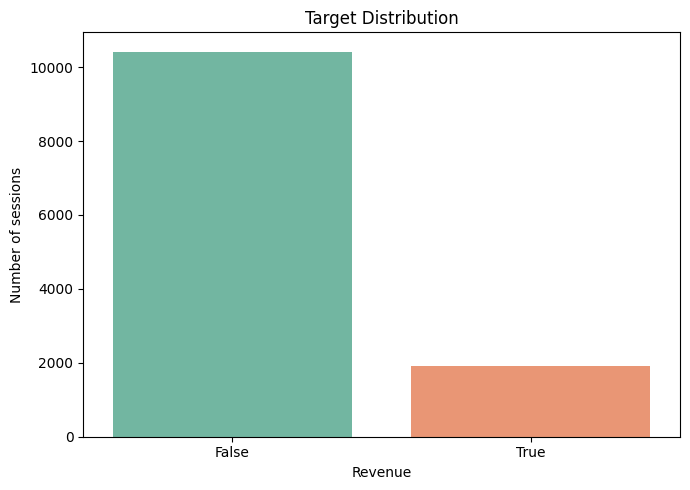

In [13]:
target_counts = df[TARGET_COLUMN].value_counts(dropna=False)
purchase_share = df[TARGET_COLUMN].mean()

display(target_counts.rename("count").to_frame())
print(f"Доля покупок: {purchase_share:.2%}")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET_COLUMN, hue=TARGET_COLUMN, palette="Set2", legend=False)
plt.title("Target Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()

# 7. EDA: числовые и категориальные признаки

Тут я разделяю признаки на группы, чтобы дальше было удобнее делать предобработку данных и анализ.

Числовые признаки складываю в `NUMERIC_FEATURES`. Это различные длительности, количество просмотров страниц, показатели отказов и другие численные характеристики поведения пользователя на сайте.

Категориальные признаки разделяю отдельно:
- текстовые (`Month`, `VisitorType`)
- числовые категории (`Browser`, `Region` и т.д.)
- булевы значения (`Weekend`).

Дальше для всех категориальных признаков смотрю распределение значений через `value_counts()`. Это помогает понять, какие категории встречаются чаще всего, есть ли редкие значения и насколько данные сбалансированы внутри признаков.

In [15]:
NUMERIC_FEATURES = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

STRING_CATEGORICAL_FEATURES = ["Month", "VisitorType"]
NUMERIC_CATEGORICAL_FEATURES = ["OperatingSystems", "Browser", "Region", "TrafficType"]
BOOLEAN_CATEGORICAL_FEATURES = ["Weekend"]
CATEGORICAL_FEATURES = STRING_CATEGORICAL_FEATURES + NUMERIC_CATEGORICAL_FEATURES + BOOLEAN_CATEGORICAL_FEATURES

display(df[NUMERIC_FEATURES].describe().T)

for column in CATEGORICAL_FEATURES:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False).to_frame("count"))

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000



Month


,count
Month,
May,3364
Nov,2998
Mar,1907
Dec,1727
Oct,549
Sep,448
Aug,433
Jul,432
June,288



VisitorType


,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


...

,count
Region,
1,4780
3,2403
4,1182
2,1136
6,805
7,761
9,511
8,434
5,318



TrafficType


,count
TrafficType,
2,3913
1,2451
3,2052
4,1069
13,738
10,450
6,444
8,343
5,260



Weekend


,count
Weekend,
False,9462
True,2868


## Вывод по данным
Во-первых, большинство пользователей не тратит много времени на административные и информационные страницы: медиана (50%) равна нулю, то есть половина сессий вообще их не касается. В то же время вкладка с продуктами явно ключевая: люди в среднем просматривают около 18–38 страниц с товарами, а в некоторых случаях — сотни.

Показатели отказов и выходов невысокие (медианные значения около 2-5%), но есть сессии с высокими показателями, что может означать, что часть пользователей быстро покидает сайт. При этом большинство сессий не приносит ценности (`PageValues` для 75% равен нулю).

По месяцам видно, что больше всего сессий в мае и ноябре — возможно, это пики активности перед праздниками или акциями. Возвращающиеся посетители — основная аудитория (85%), что значит, что повторные визиты важны для покупок.

Наконец, большинство сессий происходит не в выходные (около 77%), но покупки в выходные тоже стоит учитывать, так как их доля заметна.


# 8. EDA: графики
Здесь уже начинаю смотреть связи между признаками и искать закономерности, которые могут быть полезны модели.

Сначала строю корреляционную матрицу для числовых признаков и целевой переменной.

Дальше анализирую покупки по месяцам. Считаю среднюю долю покупок для каждого месяца и строю график. Так можно заметить сезонность и понять, в какие месяцы пользователи чаще совершают покупки.

После этого смотрю зависимость покупок от типа посетителя (`VisitorType`). Интересно проверить, кто чаще покупает: новые пользователи, возвращающиеся или другие категории посетителей.

В конце отдельно анализирую влияние выходных дней (`Weekend`). Проверяю, меняется ли вероятность покупки в зависимости от того, была ли сессия в выходной день или нет.


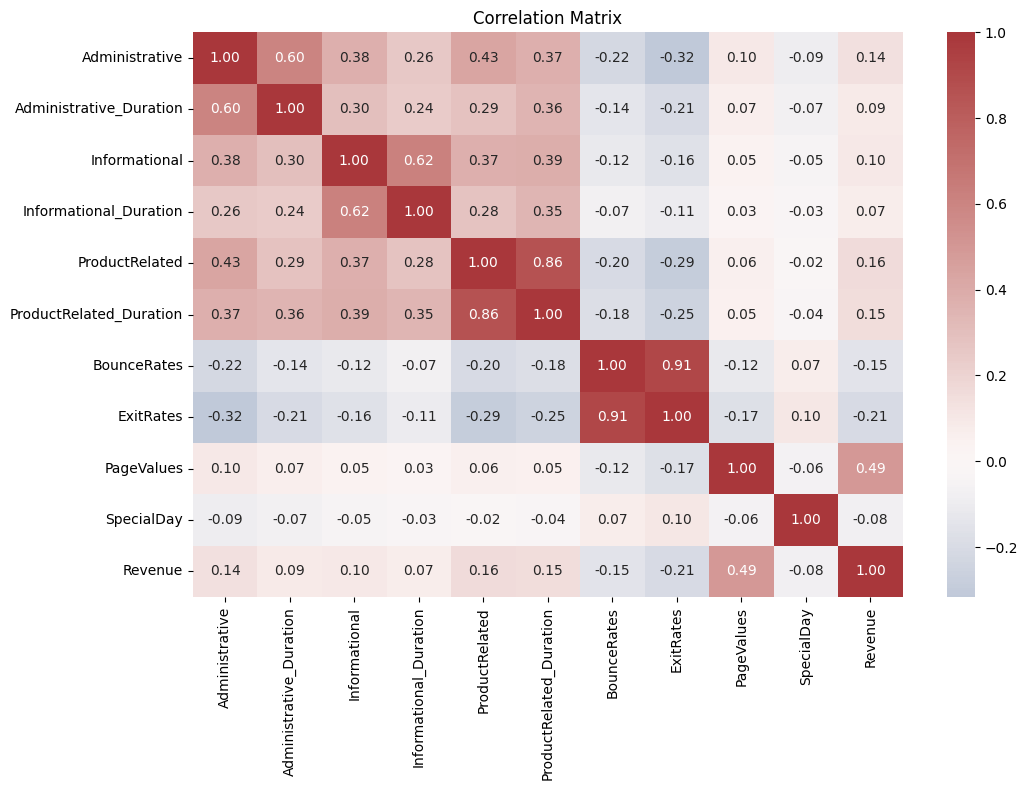

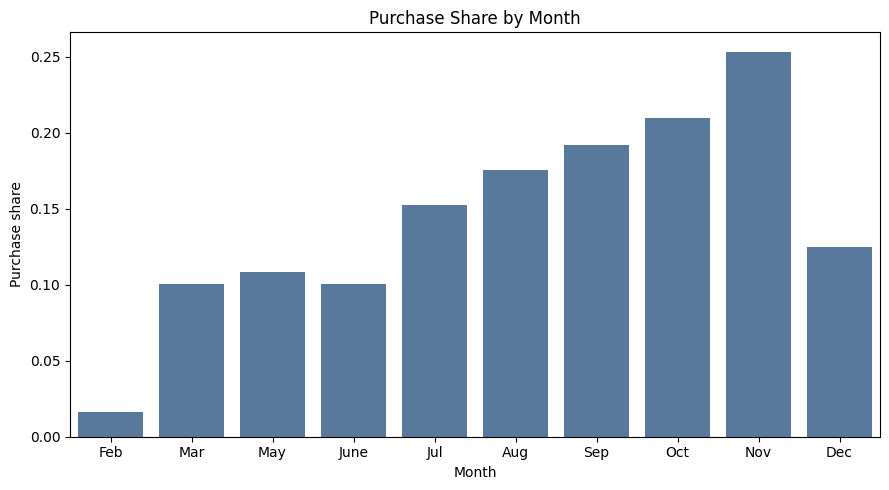

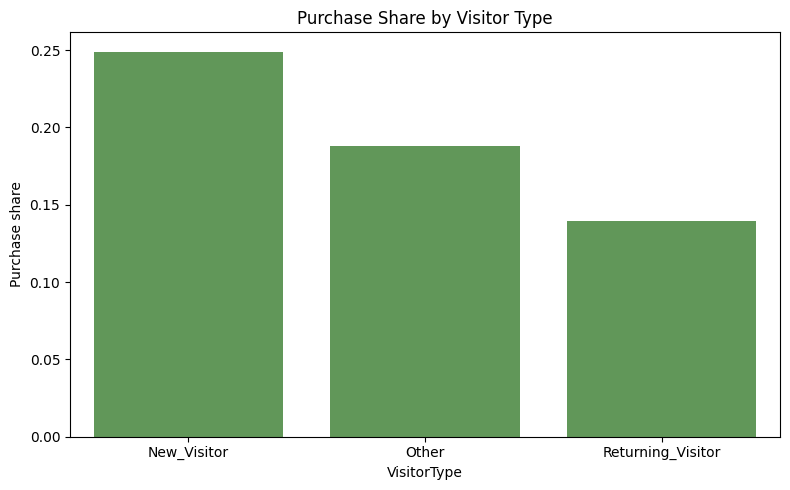

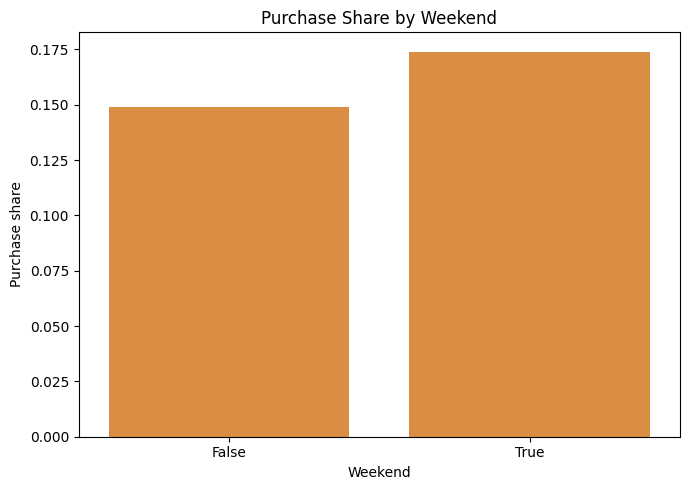

In [16]:
corr_df = df[NUMERIC_FEATURES + [TARGET_COLUMN]].copy()
corr_df[TARGET_COLUMN] = corr_df[TARGET_COLUMN].astype(int)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_revenue = df.groupby("Month", observed=False)[TARGET_COLUMN].mean().reindex(month_order).dropna().reset_index()
plt.figure(figsize=(9, 5))
sns.barplot(data=monthly_revenue, x="Month", y=TARGET_COLUMN, color="#4c78a8")
plt.title("Purchase Share by Month")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

visitor_revenue = df.groupby("VisitorType", observed=False)[TARGET_COLUMN].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=visitor_revenue, x="VisitorType", y=TARGET_COLUMN, color="#59a14f")
plt.title("Purchase Share by Visitor Type")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

weekend_revenue = df.groupby("Weekend", observed=False)[TARGET_COLUMN].mean().reset_index()
plt.figure(figsize=(7, 5))
sns.barplot(data=weekend_revenue, x="Weekend", y=TARGET_COLUMN, color="#f28e2b")
plt.title("Purchase Share by Weekend")
plt.ylabel("Purchase share")
plt.tight_layout()
plt.show()

## Анализ распределений и выбросов

В этом блоке решил подробнее посмотреть на распределение некоторых важных признаков и проверить наличие выбросов.

Сначала строю гистограммы для `PageValues`, `ExitRates` и `BounceRates` с разделением по целевой переменной `Revenue`. Это помогает визуально сравнить поведение пользователей, которые совершили покупку, и тех, кто просто покинул сайт.

Например, по таким графикам можно заметить, что у покупателей часто выше `PageValues`, а показатели отказов могут отличаться у разных классов.

Дальше через boxplot смотрю распределение всех числовых признаков сразу. Такой график хорошо показывает разброс значений, медианы и возможные выбросы.

Выбросы здесь специально не удаляю автоматически, потому что в задаче анализа поведения пользователей экстремальные значения могут быть реальными и полезными для модели. Например, очень длинная сессия или большое количество просмотренных страниц вполне могут означать заинтересованного покупателя, а не ошибку в данных.

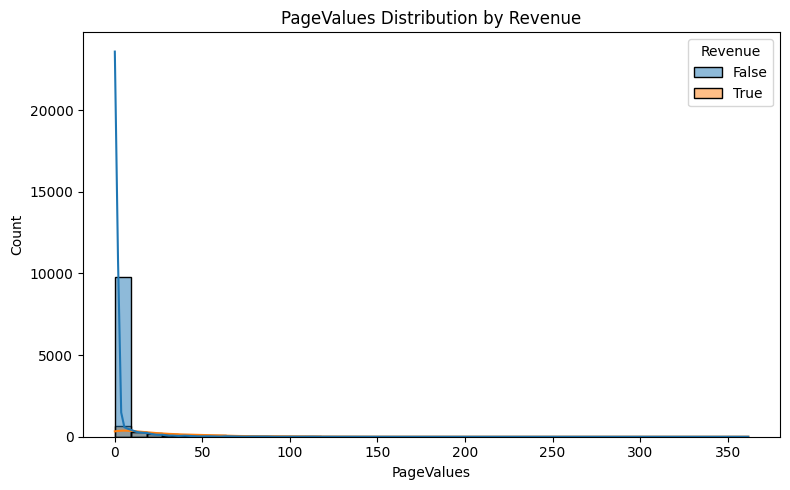

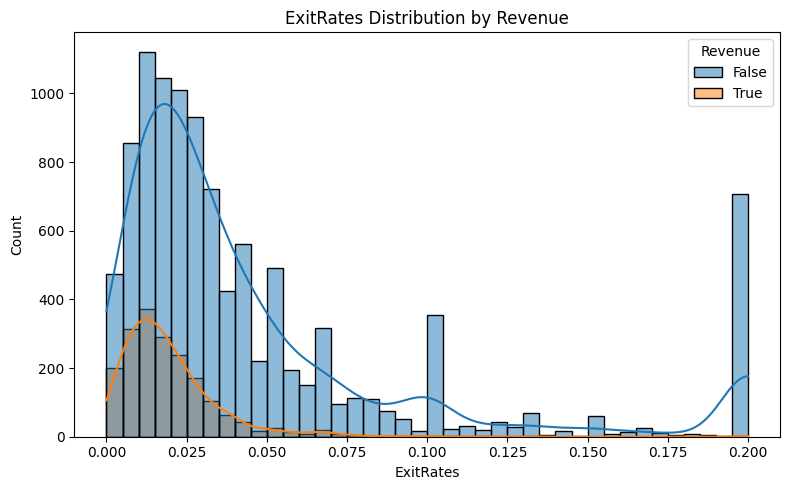

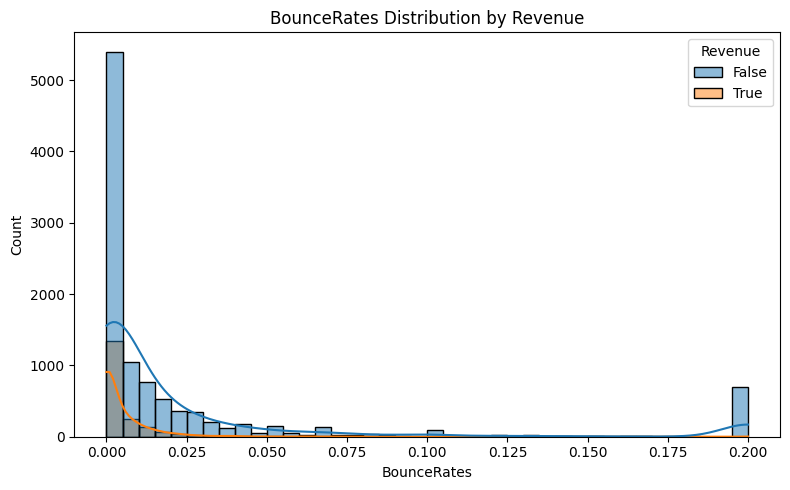

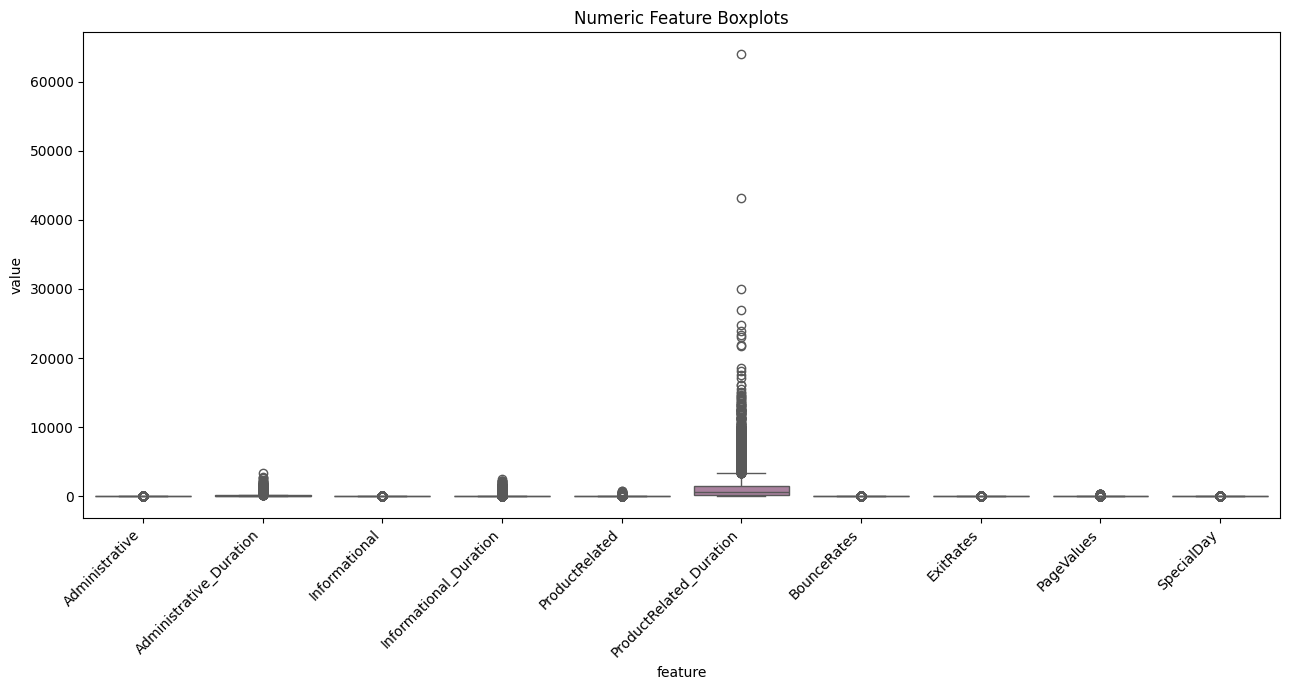

In [19]:
for feature, filename in {
    "PageValues": "pagevalues_distribution.png",
    "ExitRates": "exitrates_distribution.png",
    "BounceRates": "bouncerates_distribution.png",
}.items():
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=feature, hue=TARGET_COLUMN, bins=40, kde=True)
    plt.title(f"{feature} Distribution by Revenue")
    plt.tight_layout()
    plt.show()

melted_numeric = df[NUMERIC_FEATURES].melt(var_name="feature", value_name="value")
plt.figure(figsize=(13, 7))
sns.boxplot(data=melted_numeric, x="feature", y="value", color="#b07aa1")
plt.title("Numeric Feature Boxplots")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 9. Предобработка данных

Здесь создаю отдельную систему предобработки данных, чтобы потом одинаково и удобно обрабатывать признаки для всех моделей.

Сначала делаю функцию для создания `OneHotEncoder`. Она нужна для преобразования категориальных признаков в числовой вид, потому что модели машинного обучения не умеют работать со строками напрямую. Параметр `handle_unknown="ignore"` нужен на случай, если в тестовых данных встретится новая категория, которой не было при обучении.

Дальше создаю пайплайны для разных типов признаков.

Для числовых признаков:
- пропуски заменяются медианой,
- после этого данные масштабируются через `StandardScaler`.

Масштабирование особенно важно для логистической регрессии, потому что признаки могут иметь очень разные диапазоны значений.

Для категориальных признаков:
- пропуски заменяются самым частым значением,
- затем применяется One-Hot Encoding.

В конце всё объединяю через `ColumnTransformer`. Это позволяет автоматически применять нужную обработку к разным группам признаков и не делать всё вручную для каждого столбца.

In [20]:
def build_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    string_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )

    numeric_categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", build_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("string_categorical", string_categorical_pipeline, STRING_CATEGORICAL_FEATURES),
            ("numeric_categorical", numeric_categorical_pipeline, NUMERIC_CATEGORICAL_FEATURES),
            ("boolean_categorical", build_one_hot_encoder(), BOOLEAN_CATEGORICAL_FEATURES),
        ]
    )

# 10. Обучение моделей

Здесь разделяю данные на признаки (`X`) и целевую переменную (`y`).  
В `X` остаются все входные признаки, а `Revenue` выносится отдельно как переменная, которую модель должна будет предсказывать.

После этого делю датасет на обучающую и тестовую выборки через `train_test_split()`.

- `X_train`, `y_train` — данные для обучения моделей.
- `X_test`, `y_test` — данные для проверки качества модели на новых данных.

20% данных выделяю под тестирование (`TEST_SIZE = 0.2`).

Параметр `stratify=y` здесь особенно важен, потому что классы несбалансированы. Благодаря стратификации соотношение покупок и непокупок сохраняется примерно одинаковым и в train, и в test выборке.

In [21]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).rename("train_share"))
print(y_test.value_counts(normalize=True).rename("test_share"))

(9864, 17) (2466, 17)
Revenue
0    0.845296
1    0.154704
Name: train_share, dtype: float64
Revenue
0    0.845093
1    0.154907
Name: test_share, dtype: float64


Сначала я создаю функцию `build_models()`, где собираю несколько моделей для бинарной классификации. В качестве базовой модели беру логистическую регрессию, потом добавляю случайный лес, а также CatBoost

Функция `get_positive_scores()` нужна, чтобы получить не просто предсказанный класс, а оценку уверенности модели для положительного класса, то есть для покупки. Это нужно для расчёта кривой ROC-AUC.

Функция `evaluate_model()` считает основные метрики качества: accuracy, precision, recall, F1-score, ROC-AUC, а также confusion matrix и classification report. Так можно смотреть не только на общую точность, но и на то, насколько хорошо модель находит именно покупки.

Так удобнее выбрать лучшую модель: я смотрю не только на accuracy, а в первую очередь на F1 и ROC-AUC, потому что для этой задачи важно нормально находить пользователей, которые действительно совершат покупку.

In [24]:
def build_models() -> dict[str, Any]:
    models: dict[str, Any] = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    try:
        from catboost import CatBoostClassifier

        models["CatBoost"] = CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="F1",
            random_seed=RANDOM_STATE,
            verbose=False,
        )
    return models


def get_positive_scores(model: Any, X_data: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return np.asarray(model.decision_function(X_data))
    raise AttributeError("Model does not support predict_proba or decision_function")


def evaluate_model(model: Any, X_data: pd.DataFrame, y_true: pd.Series) -> dict[str, Any]:
    y_pred = model.predict(X_data)
    y_score = get_positive_scores(model, X_data)
    matrix = confusion_matrix(y_true, y_pred)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "confusion_matrix": matrix.tolist(),
        "classification_report": classification_report(y_true, y_pred, zero_division=0, output_dict=True),
    }


trained_models: dict[str, Pipeline] = {}
metrics_by_model: dict[str, dict[str, Any]] = {}
rows = []

for model_name, estimator in build_models().items():
    print(f"Training: {model_name}")
    pipeline = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor()),
            ("model", estimator),
        ]
    )
    pipeline.fit(X_train, y_train)
    metrics = evaluate_model(pipeline, X_test, y_test)

    trained_models[model_name] = pipeline
    metrics_by_model[model_name] = metrics

    confusion = metrics["confusion_matrix"]
    rows.append(
        {
            "model": model_name,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "tn": confusion[0][0],
            "fp": confusion[0][1],
            "fn": confusion[1][0],
            "tp": confusion[1][1],
            "confusion_matrix": json.dumps(confusion),
        }
    )

comparison = pd.DataFrame(rows).sort_values(by=["f1", "roc_auc"], ascending=False)
display(comparison)

Training: Logistic Regression
Training: Random Forest
Training: CatBoost


,model,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp,confusion_matrix
2,CatBoost,0.898216,0.717608,0.565445,0.632504,0.926114,1999,85,166,216,"[[1999, 85], [166, 216]]"
1,Random Forest,0.897810,0.766393,0.489529,0.597444,0.921264,2027,57,195,187,"[[2027, 57], [195, 187]]"
0,Logistic Regression,0.841038,0.491349,0.743455,0.591667,0.893244,1790,294,98,284,"[[1790, 294], [98, 284]]"


## Вывод по результатам моделей

По итоговым метрикам лучше всего себя показала модель CatBoost. У неё самый высокий `F1-score` (`0.63`) и лучший `ROC-AUC` (`0.93`), что говорит о наиболее сбалансированном качестве предсказаний и хорошей способности отделять покупателей от непокупателей.

Random Forest показал очень высокий `precision` (`0.77`), то есть если модель предсказывает покупку, то она чаще оказывается права. Однако `recall` у него ниже (`0.49`), из-за чего модель пропускает довольно много реальных покупателей.

Logistic Regression наоборот имеет самый высокий `recall` (`0.74`), то есть лучше остальных находит реальные покупки, но делает больше ложных срабатываний. Это видно по большому количеству `fp` (false positive). Из-за этого precision у неё заметно ниже.

Также можно заметить, что все модели показывают достаточно высокий `accuracy` (84–90%), однако из-за несбалансированности классов основное внимание стоит уделять именно `F1-score`, `precision`, `recall` и `ROC-AUC`.

В итоге для данной задачи наиболее удачным выбором оказался CatBoost, так как он обеспечивает лучший баланс между поиском реальных покупателей и количеством ложных предсказаний.

# 11. Confusion Matrix и подробный отчёт

Здесь уже более детально смотрю результаты каждой модели после обучения.

Для каждой модели отдельно вывожу confusion matrix — матрицу ошибок. Она показывает:
- сколько объектов модель определила правильно,
- где были ложные срабатывания,
- и сколько реальных покупок модель пропустила.

Это полезно, потому что одной метрики accuracy недостаточно, особенно при несбалансированных классах.

После этого вывожу `classification_report` в виде таблицы. В нём содержатся основные метрики по каждому классу:
- precision,
- recall,
- F1-score,
- support.

In [25]:
for model_name, metrics in metrics_by_model.items():
    print(f"\n=== {model_name} ===")
    print("Confusion matrix:")
    print(np.array(metrics["confusion_matrix"]))
    report = pd.DataFrame(metrics["classification_report"]).T
    display(report)


=== Logistic Regression ===
Confusion matrix:
[[1790  294]
 [  98  284]]


,precision,recall,f1-score,support
0,0.948093,0.858925,0.901309,2084.000000
1,0.491349,0.743455,0.591667,382.000000
accuracy,0.841038,0.841038,0.841038,0.841038
macro avg,0.719721,0.801190,0.746488,2466.000000
weighted avg,0.877341,0.841038,0.853343,2466.000000



=== Random Forest ===
Confusion matrix:
[[2027   57]
 [ 195  187]]


,precision,recall,f1-score,support
0,0.912241,0.972649,0.941477,2084.00000
1,0.766393,0.489529,0.597444,382.00000
accuracy,0.897810,0.897810,0.897810,0.89781
macro avg,0.839317,0.731089,0.769461,2466.00000
weighted avg,0.889648,0.897810,0.888184,2466.00000



=== CatBoost ===
Confusion matrix:
[[1999   85]
 [ 166  216]]


,precision,recall,f1-score,support
0,0.923326,0.959213,0.940927,2084.000000
1,0.717608,0.565445,0.632504,382.000000
accuracy,0.898216,0.898216,0.898216,0.898216
macro avg,0.820467,0.762329,0.786715,2466.000000
weighted avg,0.891459,0.898216,0.893150,2466.000000


# 12. Выбор лучшей модели

После сравнения всех моделей выбираю лучшую по значению `F1-score`, так как для этой задачи важно не только общее количество правильных ответов, но и баланс между precision и recall.

Из таблицы `comparison` беру модель с наилучшим результатом и сохраняю её отдельно вместе со всеми метриками.

Дальше формирую словарь `metadata`, где сохраняется основная информация о финальной модели:
- название лучшей модели,
- по какой метрике она выбиралась,
- значения основных метрик качества,
- список используемых признаков,
- название целевой переменной.

In [31]:
best_model_name = str(comparison.iloc[0]["model"])
best_model = trained_models[best_model_name]
best_metrics = metrics_by_model[best_model_name]

metadata = {
    "best_model_name": best_model_name,
    "selection_metric": "f1",
    "metrics": {
        "accuracy": float(best_metrics["accuracy"]),
        "precision": float(best_metrics["precision"]),
        "recall": float(best_metrics["recall"]),
        "f1": float(best_metrics["f1"]),
        "roc_auc": float(best_metrics["roc_auc"]),
    },
    "features": {
        "numeric": NUMERIC_FEATURES,
        "categorical": CATEGORICAL_FEATURES,
    },
    "target": TARGET_COLUMN,
}

print(f"Лучшая модель: {best_model_name}")
print(json.dumps(metadata, ensure_ascii=False, indent=2))

Лучшая модель: CatBoost
{
  "best_model_name": "CatBoost",
  "selection_metric": "f1",
  "metrics": {
    "accuracy": 0.8982157339821574,
    "precision": 0.717607973421927,
    "recall": 0.5654450261780105,
    "f1": 0.6325036603221084,
    "roc_auc": 0.9261136959733095
  },
  "features": {
    "numeric": [
      "Administrative",
      "Administrative_Duration",
      "Informational",
      "Informational_Duration",
      "ProductRelated",
      "ProductRelated_Duration",
      "BounceRates",
      "ExitRates",
      "PageValues",
      "SpecialDay"
    ],
    "categorical": [
      "Month",
      "VisitorType",
      "OperatingSystems",
      "Browser",
      "Region",
      "TrafficType",
      "Weekend"
    ]
  },
  "target": "Revenue"
}
